In [5]:
import getpass 
import os 

api_key = getpass.getpass(prompt = "Enter OpenAI API Key")
os.environ['OPENAI_API_KEY'] = api_key

In [ ]:
from crewai import Agent, Task, Crew, Process
from crewai.llm import LLM

class HTNTravelPlanner:
    def __init__(self):
        # Specialized agents
        self.flight_specialist = Agent(
            role="Flight Planning Specialist",
            goal="Handle all aspects of flight arrangements",
            backstory="Expert in airline bookings and flight logistics.",
            verbose=False
        )

        self.accomodation_specialist = Agent(
            role="Accommodation Specialist",
            goal="Manage all accommodation-related planning",
            backstory="Expert in hotel and accommodation arrangements.",
            verbose=False
        )

        self.activity_specialist = Agent(
            role="Vacation Activity Specialist",
            goal="Manage all activity-related planning",
            backstory="Expert in recreational activity arrangements.",
            verbose=False
        )

        # Manager LLM for hierarchical process
        self.llm_manager = LLM(model="gpt-4", temperature=0)

    async def plan_travel(self, request: str):
        # Define the top-level task
        travel_planning_task = Task(
            description=f"""
                Plan a comprehensive travel itinerary based on the following request:
                {request}

                The plan should include:
                - Flight arrangements
                - Accommodation bookings
                - Activities and day trips
            """,
            expected_output="A detailed travel plan covering all requested aspects.",
            agent=None  # Manager will delegate subtasks
        )

        crew = Crew(
            agents=[self.flight_specialist,
                    self.accomodation_specialist,
                    self.activity_specialist],
            tasks=[travel_planning_task],
            process=Process.hierarchical,
            manager_llm=self.llm_manager,
            verbose=False
        )

        # Async kickoff for notebooks
        return await crew.kickoff_async()

In [ ]:
planner = HTNTravelPlanner()

request = """ 
I need to plan a trip to Paris from New York for 5 days.
The plan should include:
- Flights for 2 adults 
- Hotel accommodations in central Paris with breakfast
- Airport transfers
- A day trip to Versailles.
"""

# In Jupyter, just await directly:
result = await planner.plan_travel(request=request)

print("Final Travel Plan")
print("*" * 90)
print(result)

## **Practical Implementations of Tool use and Planning**

##### **Example : CREW AI**

In [ ]:
from crewai.tools import tool 
from typing import Dict 

@tool("Search for available flights between cities")
def search_flights(origin : str , destination : str , date: str) -> Dict:
    """ 
        Search for available flights between cities.
    
    Args:
        origin: Departure city
        destination: Arrival city
        date: Travel date (YYYY-MM-DD)
    
    Returns:
        Dictionary containing flight options and prices
    """
    
    # Emulate Json data from an API
    return {
        "flights": [
            {"airline": "Air France", "price": 850, "departure": "New York (JFK)", "arrival": "Paris (CDG)", "duration": "7h 30m", "departure_time": "10:30 AM", "arrival_time": "11:00 PM"},
            {"airline": "Delta Airlines", "price": 780, "departure": "New York (JFK)", "arrival": "Paris (CDG)", "duration": "7h 45m", "departure_time": "5:30 PM", "arrival_time": "6:15 AM"},
            {"airline": "United Airlines", "price": 920, "departure": "New York (EWR)", "arrival": "Paris (CDG)", "duration": "7h 55m", "departure_time": "8:45 PM", "arrival_time": "9:40 AM"}
        ]} 


@tool("Find available hotels in a location")
def find_hotels(location : str , check_in : str , check_out : str) -> Dict:
    """
    Search for available hotels in a location.
    
    Args:
        location: City name
        check_in: Check-in date (YYYY-MM-DD)
        check_out: Check-out date (YYYY-MM-DD)
    
    Returns:
        Dictionary containing hotel options and prices
    """
    # Emulate JSON data from an API
    return {
        "hotels": [
            {"name": "Paris Marriott Champs Elysees", "price": 450, "check_in_date": check_in, "check_out_date": check_out, "rating": 4.5, "location": "Central Paris", "amenities": ["Spa", "Restaurant", "Room Service"]},
            {"name": "Citadines Saint-Germain-des-Prés", "price": 280, "check_in_date": check_in, "check_out_date": check_out, "rating": 4.2, "location": "Saint-Germain", "amenities": ["Kitchenette", "Laundry", "Wifi"]},
            {"name": "Ibis Paris Eiffel Tower", "price": 180, "check_in_date": check_in, "check_out_date": check_out, "rating": 4.0, "location": "Near Eiffel Tower", "amenities": ["Restaurant", "Bar", "Wifi"]}
        ]}


@tool("Find available activities in a location")
def find_activities(location : str , date : str , preferences : str) -> Dict:
    """
    Find available activities in a location.
    
    Args:
        location: City name
        date: Activity date (YYYY-MM-DD)
        preferences: Activity preferences/requirements
        
    Returns:
        Dictionary containing activity options
    """
    # Implement actual activity search logic here
    return {
        "activities": [
            {"name": "Eiffel Tower Skip-the-Line", "description": "Priority access to the Eiffel Tower with guided tour of 1st and 2nd floors", "price": 65, "duration": "2 hours", "start_time": "10:00 AM", "meeting_point": "Eiffel Tower South Entrance"},
            {"name": "Louvre Museum Guided Tour", "description": "Expert-guided tour of the Louvre's masterpieces including Mona Lisa", "price": 85, "duration": "3 hours", "start_time": "2:00 PM", "meeting_point": "Louvre Pyramid"},
            {"name": "Seine River Dinner Cruise", "description": "Evening cruise along the Seine with 3-course French dinner and wine", "price": 120, "duration": "2.5 hours", "start_time": "7:30 PM", "meeting_point": "Port de la Bourdonnais"}
        ]}


In [ ]:
from crewai import Agent, Task, Crew , Process 
from langchain_openai import ChatOpenAI
from typing import Dict 

class TravelPlannerCrewAI:
    def __init__(self):
        # Create specialized agents for different aspects of travel planning
        self.travel_specialist = Agent(
            role='An expert travel concierge',
            goal='Handle all aspects of travel planning',
            backstory="Expert in airline bookings and flight logistics, hotel bookings, and booking vacation activities.",
            tools=[search_flights, find_hotels, find_activities],
            verbose=False
        )

    async def plan_travel(self, request : str) -> Dict:
        # Define the top level task for travel planning
        travel_planning_task = Task(
            description = f""" Plan a comprehensive travel and leisure itinerary based on the following request: 
            {request}
            The plan should include:
            - Flight arrangements
            - Accodmodation bookings
            - Any other relevant travel components
            """,
            expected_output="A detailed travel itinerary covering all requested aspects.",
            agent=self.travel_specialist
        )

        crew = Crew(
            agents= [self.travel_specialist],
            tasks=[travel_planning_task],
            process = Process.sequential,
            verbose=False
        )

        return await crew.kickoff_async()

In [ ]:
planner = TravelPlannerCrewAI()
request = "I need to plan a trip to Paris from New York for 5 days."
result = await planner.plan_travel(request=request)

In [ ]:
print(result)

##### **Example : AUTOGEN**

In [6]:

from autogen_agentchat.agents import AssistantAgent
from autogen_agentchat.conditions import (
    TextMentionTermination,
    MaxMessageTermination,
)
from autogen_agentchat.teams import RoundRobinGroupChat
from autogen_agentchat.ui import Console
from autogen_ext.models.openai import OpenAIChatCompletionClient


model_client = OpenAIChatCompletionClient(
    model="gpt-4o-mini",
    api_key=api_key
)


class TravelTools:

    def search_flights(
        self,
        origin: str,
        destination: str,
        date: str,
    ) -> dict:
        """Search for available flights between cities."""

        return {
            "flights": [
                {
                    "airline": "Air France",
                    "price": 850,
                    "departure": "New York (JFK)",
                    "arrival": "Paris (CDG)",
                    "duration": "7h 30m",
                },
                {
                    "airline": "Delta Airlines",
                    "price": 780,
                    "departure": "New York (JFK)",
                    "arrival": "Paris (CDG)",
                    "duration": "7h 45m",
                },
            ]
        }

    def find_hotels(
        self,
        location: str,
        check_in: str,
        check_out: str,
    ) -> dict:
        """Search for available hotels."""

        return {
            "hotels": [
                {
                    "name": "Paris Marriott Champs Elysees",
                    "price": 450,
                    "rating": 4.5,
                },
                {
                    "name": "Citadines Saint-Germain-des-Pres",
                    "price": 280,
                    "rating": 4.2,
                },
            ]
        }

    def find_activities(
        self,
        location: str,
        date: str,
        preferences: str,
    ) -> dict:
        """Find activities."""

        return {
            "activities": [
                {
                    "name": "Eiffel Tower Tour",
                    "price": 65,
                },
                {
                    "name": "Louvre Guided Tour",
                    "price": 85,
                },
            ]
        }


travel_tools = TravelTools()


flight_agent = AssistantAgent(
    name="flight_planner",
    model_client=model_client,
    tools=[travel_tools.search_flights],
    description="Flight planning specialist.",
    system_message="""
You are a flight planning specialist.

Use the flight search tool.
Provide flight recommendations only.

Do not ask follow-up questions.
Do not summarize the entire trip.
""",
)


hotel_agent = AssistantAgent(
    name="hotel_planner",
    model_client=model_client,
    tools=[travel_tools.find_hotels],
    description="Hotel booking specialist.",
    system_message="""
You are a hotel booking specialist.

Use the hotel search tool.
Provide hotel recommendations only.

Do not summarize the entire trip.
""",
)


activities_agent = AssistantAgent(
    name="activities_planner",
    model_client=model_client,
    tools=[travel_tools.find_activities],
    description="Activities specialist.",
    system_message="""
You are an activities specialist.

Use the activities tool.
Recommend activities only.

Do not summarize the entire trip.
""",
)



summary_agent = AssistantAgent(
    name="travel_summary_agent",
    model_client=OpenAIChatCompletionClient(
        model="gpt-4o"
    ),
    description="Creates final travel plan.",
    system_message="""
You are the final travel planner.

After reviewing all prior messages:

1. Create a complete 5-day itinerary.
2. Include flight recommendation.
3. Include hotel recommendation.
4. Include activities recommendation.
5. End your response with EXACTLY:

TERMINATE

Do not ask questions.
Do not continue discussion.
""",
)



termination = (
    TextMentionTermination("TERMINATE")
    | MaxMessageTermination(8)
)



group_chat = RoundRobinGroupChat(
    participants=[
        flight_agent,
        hotel_agent,
        activities_agent,
        summary_agent,
    ],
    termination_condition=termination,
)



await Console(
    group_chat.run_stream(
        task="I need to plan a trip to Paris from New York for 5 days."
    )
)


---------- TextMessage (user) ----------
I need to plan a trip to Paris from New York for 5 days.
---------- ToolCallRequestEvent (flight_planner) ----------
[FunctionCall(id='call_gu8wg0YGTOLlSCFD4AmvftDC', arguments='{"origin": "New York", "destination": "Paris", "date": "2024-05-01"}', name='search_flights'), FunctionCall(id='call_ridBNVwhoAfQ0NPS9V7yvWzk', arguments='{"origin": "Paris", "destination": "New York", "date": "2024-05-06"}', name='search_flights')]
---------- ToolCallExecutionEvent (flight_planner) ----------
[FunctionExecutionResult(content="{'flights': [{'airline': 'Air France', 'price': 850, 'departure': 'New York (JFK)', 'arrival': 'Paris (CDG)', 'duration': '7h 30m'}, {'airline': 'Delta Airlines', 'price': 780, 'departure': 'New York (JFK)', 'arrival': 'Paris (CDG)', 'duration': '7h 45m'}]}", name='search_flights', call_id='call_gu8wg0YGTOLlSCFD4AmvftDC', is_error=False), FunctionExecutionResult(content="{'flights': [{'airline': 'Air France', 'price': 850, 'departu

TaskResult(messages=[TextMessage(id='c80eea9c-6c47-4c58-a4e8-7056f541fa46', source='user', models_usage=None, metadata={}, created_at=datetime.datetime(2026, 6, 18, 16, 56, 44, 274301, tzinfo=datetime.timezone.utc), content='I need to plan a trip to Paris from New York for 5 days.', type='TextMessage'), ToolCallRequestEvent(id='45d24e20-8256-4867-8e40-cbb2db761b2f', source='flight_planner', models_usage=RequestUsage(prompt_tokens=119, completion_tokens=74), metadata={}, created_at=datetime.datetime(2026, 6, 18, 16, 56, 47, 238363, tzinfo=datetime.timezone.utc), content=[FunctionCall(id='call_gu8wg0YGTOLlSCFD4AmvftDC', arguments='{"origin": "New York", "destination": "Paris", "date": "2024-05-01"}', name='search_flights'), FunctionCall(id='call_ridBNVwhoAfQ0NPS9V7yvWzk', arguments='{"origin": "Paris", "destination": "New York", "date": "2024-05-06"}', name='search_flights')], type='ToolCallRequestEvent'), ToolCallExecutionEvent(id='43e9ed4c-76dd-4715-8b27-557baa28b9bf', source='flight_p

##### **Example : AUTOGEN**

In [7]:
# Import Modules 

from typing import List, TypedDict
import operator
from langchain_core.messages import BaseMessage,HumanMessage,AIMessage
from langgraph.graph import StateGraph, END

# Structure of the langgraph
class TravelState(TypedDict):
    messages : List[BaseMessage]

In [8]:
# Import toolnode from prebuild submodule
from langchain_core.tools import tool 
from langgraph.prebuilt import ToolNode
import json 

@tool
def search_flight_lg(origin : str , destination : str , date : str) -> dict:
    """
    Search for available flights between cities.
    
    Args:
        origin: Departure city
        destination: Arrival city
        date: Travel date (YYYY-MM-DD)
    
    Returns:
        Dictionary containing flight options and prices
    """
    # Emulate JSON data from an API
    return json.dumps({
        "flights": [
            {"airline": "Air France", "price": 850, "departure": "New York (JFK)", "arrival": "Paris (CDG)", "duration": "7h 30m", "departure_time": "10:30 AM", "arrival_time": "11:00 PM"},
            {"airline": "Delta Airlines", "price": 780, "departure": "New York (JFK)", "arrival": "Paris (CDG)", "duration": "7h 45m", "departure_time": "5:30 PM", "arrival_time": "6:15 AM"},
            {"airline": "United Airlines", "price": 920, "departure": "New York (EWR)", "arrival": "Paris (CDG)", "duration": "7h 55m", "departure_time": "8:45 PM", "arrival_time": "9:40 AM"}
        ]}) 


@tool
def find_hotels_lg(location : str , check_in : str , check_out : str) -> dict:
    """
    Search for available hotels in a location.
    
    Args:
        location: City name
        check_in: Check-in date (YYYY-MM-DD)
        check_out: Check-out date (YYYY-MM-DD)
    
    Returns:
        Dictionary containing hotel options and prices
    """
    # Emulate JSON data from an API
    return json.dumps({
        "hotels": [
            {"name": "Paris Marriott Champs Elysees", "price": 450, "check_in_date": check_in, "check_out_date": check_out, "rating": 4.5, "location": "Central Paris", "amenities": ["Spa", "Restaurant", "Room Service"]},
            {"name": "Citadines Saint-Germain-des-Prés", "price": 280, "check_in_date": check_in, "check_out_date": check_out, "rating": 4.2, "location": "Saint-Germain", "amenities": ["Kitchenette", "Laundry", "Wifi"]},
            {"name": "Ibis Paris Eiffel Tower", "price": 180, "check_in_date": check_in, "check_out_date": check_out, "rating": 4.0, "location": "Near Eiffel Tower", "amenities": ["Restaurant", "Bar", "Wifi"]}
        ]})


@tool 
def find_activities_lg(location : str , date : str , preferences : str) -> dict:
    """
    Find available activities in a location.
    
    Args:
        location: City name
        date: Activity date (YYYY-MM-DD)
        preferences: Activity preferences/requirements
        
    Returns:
        Dictionary containing activity options
    """
    # Implement actual activity search logic here
    return json.dumps({
        "activities": [
            {"name": "Eiffel Tower Skip-the-Line", "description": "Priority access to the Eiffel Tower with guided tour of 1st and 2nd floors", "price": 65, "duration": "2 hours", "start_time": "10:00 AM", "meeting_point": "Eiffel Tower South Entrance"},
            {"name": "Louvre Museum Guided Tour", "description": "Expert-guided tour of the Louvre's masterpieces including Mona Lisa", "price": 85, "duration": "3 hours", "start_time": "2:00 PM", "meeting_point": "Louvre Pyramid"},
            {"name": "Seine River Dinner Cruise", "description": "Evening cruise along the Seine with 3-course French dinner and wine", "price": 120, "duration": "2.5 hours", "start_time": "7:30 PM", "meeting_point": "Port de la Bourdonnais"}
        ]})


tools = [search_flight_lg , find_hotels_lg , find_activities_lg]
tool_node = ToolNode(tools)

In [9]:
from langchain_openai import ChatOpenAI
llm_with_tools = ChatOpenAI(model="gpt-4o-mini").bind_tools(tools)
resp = llm_with_tools.invoke("Book a flight to Paris from New York on any future date").tool_calls
resp 

[{'name': 'search_flight_lg',
  'args': {'origin': 'New York', 'destination': 'Paris', 'date': '2024-04-01'},
  'id': 'call_uTYDEnhnKCzm4DjiBCbQZrba',
  'type': 'tool_call'}]

In [10]:
from typing import Literal
from langgraph.graph import StateGraph,MessagesState, START,END

def should_continue(state : MessagesState):
    messages = state['messages']
    last_message = messages[-1]
    if last_message.tool_calls:
        return "tools"
    return END

def call_model(state : MessagesState):
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {"messages" : [response]}

workflow = StateGraph(MessagesState)

# Define the two nodes we will cycle between them
workflow.add_node("agent" , call_model)
workflow.add_node("tools" , tool_node)

workflow.add_edge(START , "agent")
workflow.add_conditional_edges("agent" , should_continue , ['tools' , END])     # In the mordern langgraph just need agent and should_continue 
workflow.add_edge("tools" , "agent")

app = workflow.compile()

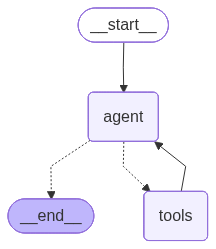

In [11]:
from IPython.display import Image,display
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Error in drawing :- " , str(e))

In [13]:
for chunk in app.stream(
    {'messages' : [('human' , 'I need to plan a trip to Paris from New York for 5 days, use any future date, Budget hotels and sightseeing preferred')]} , 
    stream_mode = "values"
):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

I need to plan a trip to Paris from New York for 5 days, use any future date, Budget hotels and sightseeing preferred
================================== Ai Message ==================================
Tool Calls:
  search_flight_lg (call_kLj3Jdu5DXmUROzw8XXsEOYB)
 Call ID: call_kLj3Jdu5DXmUROzw8XXsEOYB
  Args:
    origin: New York
    destination: Paris
    date: 2024-05-01
  find_hotels_lg (call_Q9v0lbELwecMa87uWO2nH7v9)
 Call ID: call_Q9v0lbELwecMa87uWO2nH7v9
  Args:
    location: Paris
    check_in: 2024-05-01
    check_out: 2024-05-06
  find_activities_lg (call_xgSBoXmsbTqy2aIhz8Spy1j4)
 Call ID: call_xgSBoXmsbTqy2aIhz8Spy1j4
  Args:
    location: Paris
    date: 2024-05-01
    preferences: sightseeing
================================= Tool Message =================================
Name: find_activities_lg

{"activities": [{"name": "Eiffel Tower Skip-the-Line", "description": "Priority access to the Eif